# Notebook 1 — Pipeline Walkthrough (Part 1)

## Synthetic Edge Cases for AI Training

Welcome to the first notebook in the Edge-Case Synthesis bootcamp.

In this session we start building the pipeline **step by step**. Today we cover:

1. **Load real images** — our pipeline edits real photos; it does not invent scenes from scratch.
2. **Depth estimation** — capture scene geometry so diffusion keeps perspective and layout.
3. **Segmentation** — ADE20K-colored maps for ControlNet-seg (+ edit masks for localized inserts).
4. **MultiControlNet + diffusion** — depth + seg lock, prompt-driven anomaly inserts.
5. **Auto-annotation** — open-vocabulary detections + SAM masks on synthetic outputs.

(VLM judging and batch dataset generation come in later notebooks.)

### Learning objectives

By the end of this notebook you should be able to:

- Explain *why* we start from real images instead of generating from text alone.
- Run a local depth model and interpret its output.
- Run a local segmentation model and read the colored region map.
- Articulate which artifacts are sent to **ControlNet** (depth + ADE20K seg) vs which models come later (VLM judge).
- Swap **plug-and-play anomaly configs** under `configs/generation/anomalies/<dataset>/`.

### Hardware profiles (swap with one line)

| Profile | Machine | Object inserts | Weather | Depth / Seg / Annotate |
|---------|---------|----------------|---------|------------------------|
| **`cpu`** (default) | laptop / MPS | `paste` | SD 1.5 + depth CN | DA-V2 Base, SegFormer-B0, OWL-ViT-B + MobileSAM |
| **`gpu_l4`** | g2-standard-8 (1× NVIDIA L4 24 GB) | **SDXL inpaint** | SDXL + depth CN | DA-V2 Large, SegFormer-B2, OWL-ViT-L + SAM-B |

```python
cfg = load_config(start=PROJECT_ROOT, overrides=["hardware=gpu_l4"])
```

Configs: `configs/hardware/cpu.yaml` and `configs/hardware/gpu_l4.yaml`.

> **MobileSAM vs ControlNet-seg:** MobileSAM is great for *annotation* masks. We do **not** feed its random colors into ControlNet-seg — that ControlNet was trained on the ADE20K palette. SegFormer / remapped RailSem19 GT provide those colors.

> Implementation lives in `src/edgecase_synthesis/`. This notebook orchestrates and visualizes.


---
## 0. Environment setup

From the **repository root**:

```bash
./scripts/setup_notebook_env.sh
```

### Select a kernel

1. In the notebook, click **Select Kernel** (top-right)
2. Choose **Jupyter Kernel…** → **`EdgeCase Synthesis (.venv)`**

If the picker fails, enter the interpreter path manually:

```
/Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/.venv/bin/python3.12
```

The cell below adds the project package to the path when you run the notebook from `notebooks/`.

In [13]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/implementations/edge_case_image_generation


---
## 1. Load real images

### Why start from real photos?

Safety-critical datasets have a **long-tail problem**: rare events (ice on rails, fallen trees, small defects) appear in only a handful of photos among tens of thousands of normal ones.

Collecting those rare cases is expensive. Our pipeline **edits** existing real images to introduce rare conditions while preserving camera viewpoint, geometry, and lighting — so synthetic examples stay close to the deployment distribution.

### Image source (Hydra-managed)

Configs live under **`configs/`** and are composed with [Hydra](https://hydra.cc/). The active image source is selected in **`configs/config.yaml`**:

```yaml
defaults:
  - data/source@data: railsem19   # or: nordland_hf, l4r_nlb, wikimedia, local
```

Or override at runtime in the notebook:

```python
cfg = load_config(overrides=["data/source@data=nordland_hf"])
```

| Source | What you get |
|--------|--------------|
| **`railsem19`** (default) | Five curated cab/track frames from local [RailSem19](https://wilddash.cc/railsem19) validation under `data/rs19_val/` (research / rail-road safety CV terms). |
| **`nordland_hf`** | Nordlandsbanen frames from [Somayeh-h/Nordland](https://huggingface.co/datasets/Somayeh-h/Nordland) (CC BY-NC-SA 4.0), streamed via the HF datasets API. |
| **`l4r_nlb`** | Annotated cab-view frames (CC BY 3.0). Downloads `L4R_NLB_fall.zip` (~3.3 GB) from [Zenodo](https://zenodo.org/records/14260575) on first run. |
| **`wikimedia`** | Three license-friendly Commons photos — quick fallback. |
| **`local`** | Whatever you drop into `data/samples/` yourself. |

> **RailSem19 note:** frames are copied from `data/rs19_val/jpgs/rs19_val/` into `data/samples/` (list in `configs/data/source/railsem19.yaml`). No download.

In [ ]:
from edgecase_synthesis.config import load_config
from edgecase_synthesis.data import (
    get_data_source_info,
    load_sample_images,
    prepare_sample_images,
)
from edgecase_synthesis.viz import show_samples

# Flip the whole model stack: "cpu" (laptop) or "gpu_l4" (g2-standard-8 / NVIDIA L4).
HARDWARE = "cpu"  # change to "gpu_l4" on the L4 VM

# Optional data override, e.g. "data/source@data=nordland_hf"
overrides = [f"hardware={HARDWARE}"]
# overrides.append("data/source@data=nordland_hf")

cfg = load_config(start=PROJECT_ROOT, overrides=overrides)

source_info = get_data_source_info(cfg)
samples_dir = Path(cfg.paths.samples_dir)
samples_dir.mkdir(parents=True, exist_ok=True)

print(f"Hardware profile: {cfg.hardware.name}  (device={cfg.hardware.device})")
print(f"Active source: {source_info.label}")
print(f"License: {source_info.license}")
print(f"Samples folder: {samples_dir}")
print(f"Depth model: {cfg.conditioning.depth.model_id}")
print(f"Seg backend: {cfg.conditioning.segmentation.model_name}")
print(f"Generation family: {cfg.generation.family}  default_method={cfg.generation.default_anomaly_method}")
print(f"Annotation: {cfg.annotation.detector_model} + {cfg.annotation.sam_model}")

downloaded = prepare_sample_images(samples_dir, cfg=cfg)
print(f"Prepared {len(downloaded)} image(s)")

samples = load_sample_images(samples_dir, cfg=cfg)
print(f"Loaded {len(samples)} images for this notebook.")


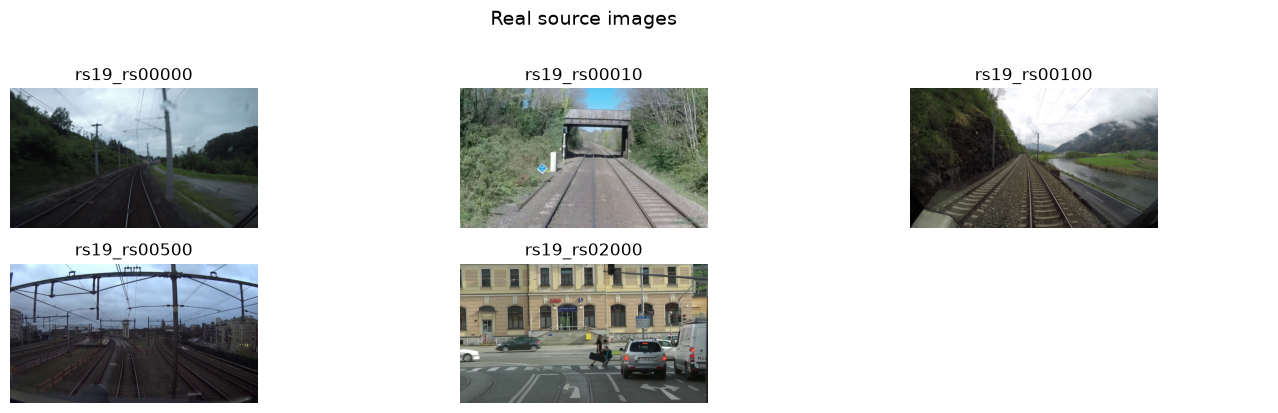

In [15]:
show_samples(samples, ncol=min(3, len(samples)), figsize=(14, 4));

**Checkpoint:** You should see five **real** RailSem19 cab/track photos (`rs19_rs00000`, …). Each `ImageSample` carries the PIL image, file path, and a short name we reuse when saving artifacts.

If `data/rs19_val/` is missing, re-run with `load_config(start=PROJECT_ROOT, overrides=["data/source@data=nordland_hf"])` or `wikimedia`.

---
## 2. Depth estimation

Depth Anything V2 estimates **relative depth** per pixel (Base on `cpu`, Large on `gpu_l4`). Brighter / warmer colors in the colormap usually mean **closer** objects.

What to look for in a good depth map:

- Near ground / ballast vs far sky
- Smooth gradients along the track perspective
- Poles and embankments as mid-range structure

Rails themselves are thin and nearly coplanar with ballast — monocular depth usually will **not** carve them out as separate depths. That is fine: ControlNet-depth needs the ground plane and camera layout, not pixel-perfect rail lines.

> This depth map is a **ControlNet conditioning input**. It is **not** sent to the VLM judge later.


In [ ]:
import importlib

import edgecase_synthesis.conditioning as conditioning_mod

importlib.reload(conditioning_mod)
from edgecase_synthesis.conditioning import DepthEstimator

depth_model = DepthEstimator.from_config(cfg)
print(f"Depth model loaded: {depth_model.model_id} on {depth_model.device}")


Depth map shape: (1080, 1920)
Depth range: [0.000, 1.000]


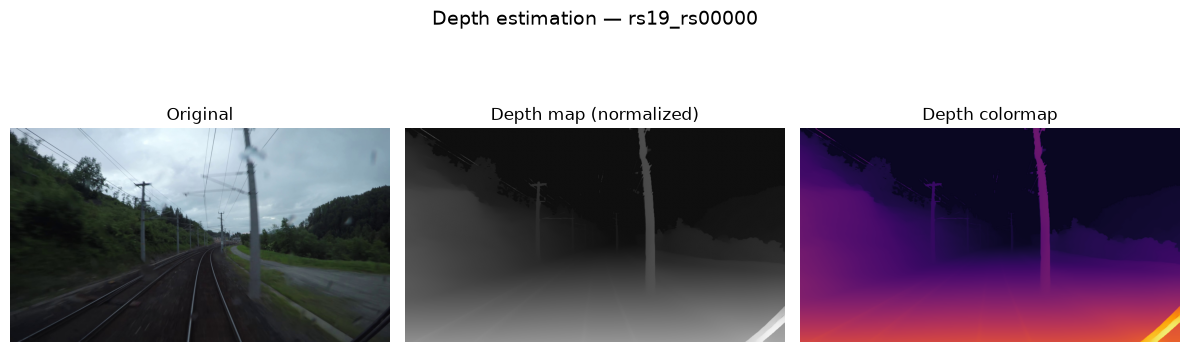

In [17]:
from edgecase_synthesis.viz import show_depth_result

# Run on our first sample — we'll batch the rest in a moment.
sample = samples[0]
depth_result = depth_model.predict(sample.image)

print(f"Depth map shape: {depth_result.depth_map.shape}")
print(f"Depth range: [{depth_result.depth_map.min():.3f}, {depth_result.depth_map.max():.3f}]")

show_depth_result(sample, depth_result);

In [18]:
# Depth maps for every loaded sample
depth_results = {s.name: depth_model.predict(s.image) for s in samples}

for s in samples:
    d = depth_results[s.name]
    print(f"{s.name}: {d.depth_map.shape}, regions roughly separable by depth")

rs19_rs00000: (1080, 1920), regions roughly separable by depth
rs19_rs00010: (1080, 1920), regions roughly separable by depth
rs19_rs00100: (1080, 1920), regions roughly separable by depth
rs19_rs00500: (1080, 1920), regions roughly separable by depth
rs19_rs02000: (1080, 1920), regions roughly separable by depth


---
## 3. Segmentation

We need a **semantic** map in the **ADE20K color protocol** for ControlNet-seg.

**Why not MobileSAM here?** MobileSAM (and classic SAM) produce instance masks with *arbitrary* colors. `lllyasviel/sd-controlnet-seg` was trained on ADE20K palette colors — random SAM colors break geometry. MobileSAM still shines later for **annotation**.

For RailSem19 samples we prefer the **GT uint8 labels** when present (best track / trackbed), remapped to ADE20K-ish colors for ControlNet.

The segmenter also exposes helpers used by anomaly configs to build a localized **edit mask** (where the cone / branch / animal is allowed to appear).


In [ ]:
import importlib

import edgecase_synthesis.conditioning as conditioning_mod

importlib.reload(conditioning_mod)
from edgecase_synthesis.conditioning import Segmenter

# If this still errors, restart the kernel and re-run from Section 0 —
# a stale Segmenter from before the SegFormer switch will try to load this
# HF id as an Ultralytics *.pt SAM weight.
segmenter = Segmenter.from_config(cfg)
print(f"Segmentation backend: {segmenter.model_name} on {segmenter.device}")
print("(SegFormer weights load only if RailSem19 GT labels are missing.)")


RailSem19 GT labels: /Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/implementations/edge_case_image_generation/data/rs19_val/uint8/rs19_val/rs00000.png
Found 12 region(s)
Edit mask coverage: 5.3% of pixels


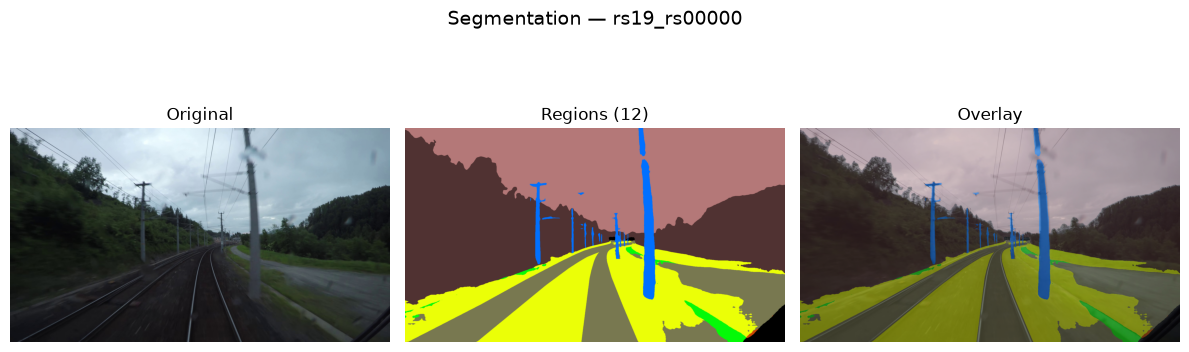

In [20]:
from edgecase_synthesis.conditioning import find_railsem19_label_map
from edgecase_synthesis.viz import show_segmentation_result

sample = samples[0]
label_path = find_railsem19_label_map(
    sample.path,
    dataset_root=cfg.paths.get("railsem19_dir"),
)
print(f"RailSem19 GT labels: {label_path or '(none — using SegFormer)'}")

seg_result = segmenter.predict(sample.image, label_map_path=label_path)
print(f"Found {seg_result.num_regions} region(s)")
if seg_result.edit_mask is not None:
    print(f"Edit mask coverage: {100 * seg_result.edit_mask.mean():.1f}% of pixels")
show_segmentation_result(sample, seg_result);

In [21]:
seg_results = {}
for s in samples:
    label_path = find_railsem19_label_map(
        s.path,
        dataset_root=cfg.paths.get("railsem19_dir"),
    )
    seg_results[s.name] = segmenter.predict(s.image, label_map_path=label_path)

for s in samples:
    n = seg_results[s.name].num_regions
    cov = seg_results[s.name].edit_mask
    cov_pct = 100 * cov.mean() if cov is not None else 0.0
    print(f"{s.name}: {n} region(s), edit_mask={cov_pct:.1f}%")

rs19_rs00000: 12 region(s), edit_mask=5.3%
rs19_rs00010: 13 region(s), edit_mask=4.4%
rs19_rs00100: 14 region(s), edit_mask=4.4%
rs19_rs00500: 16 region(s), edit_mask=12.7%
rs19_rs02000: 14 region(s), edit_mask=4.7%


---
## 4. Structure extraction summary

For each real image we now have:

| Artifact | Used by | Purpose |
|----------|---------|---------|
| Original image | Diffusion (img2img) | Starting point for controlled edits |
| Depth map | ControlNet-depth | Preserve scene geometry / perspective |
| ADE20K seg map | ControlNet-seg | Preserve region layout (palette-matched) |
| Edit mask (per anomaly) | Composite + optional priming | Localize the insert so the rest of the photo stays intact |

These maps guide diffusion. They are **not** sent to the VLM judge later.


Saved artifacts:
  depth_npy: /Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/implementations/edge_case_image_generation/outputs/depth/rs19_rs00000_depth.npy
  depth_png: /Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/implementations/edge_case_image_generation/outputs/depth/rs19_rs00000_depth.png
  segmentation_png: /Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/implementations/edge_case_image_generation/outputs/segmentation/rs19_rs00000_seg.png
  overlay_png: /Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/implementations/edge_case_image_generation/outputs/segmentation/rs19_rs00000_overlay.png
  edit_mask_png: /Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/implementations/edge_case_image_generation/outputs/segmentation/rs19_rs00000_edit_mask.png


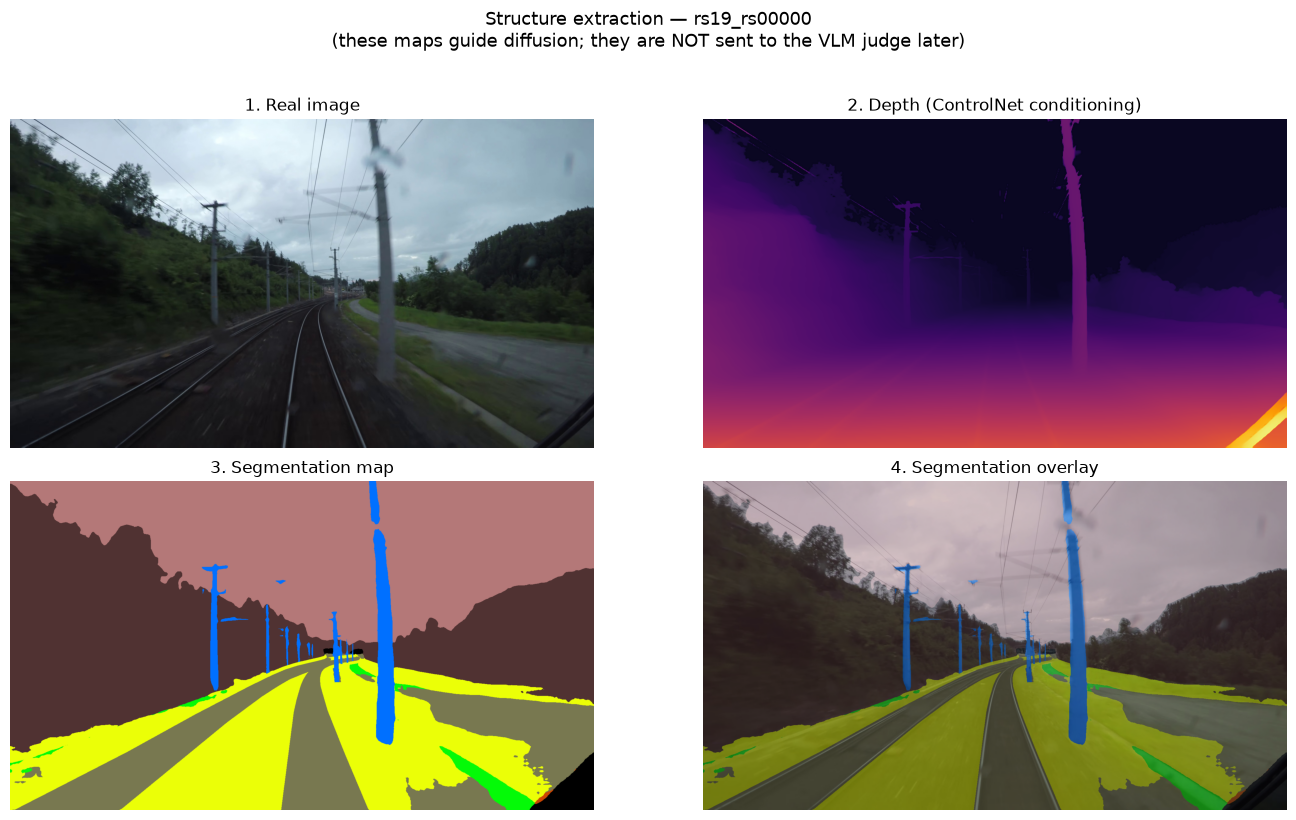

In [22]:
from edgecase_synthesis.viz import save_structure_artifacts, show_structure_overview

sample = samples[0]
show_structure_overview(sample, depth_results[sample.name], seg_results[sample.name]);

output_dir = Path(cfg.paths.outputs_dir)
saved = save_structure_artifacts(
    sample,
    depth_results[sample.name],
    seg_results[sample.name],
    output_dir,
)
print("Saved artifacts:")
for key, path in saved.items():
    print(f"  {key}: {path}")

---
## 5. Controlled generation (plug-and-play anomalies)

**Important lesson:** depth ControlNet is great at *preserving* track geometry — which means it **fights inserting new objects** on the rails (it redraws tracks inside the mask instead of a cone/deer).

Anomaly YAMLs use `method: auto` so the hardware profile picks the insert strategy:

| Method | Profile | What it does |
|--------|---------|--------------|
| `paste` | `cpu` default | Render object + soft shadow, composite (seconds, no diffusion) |
| `inpaint` | `gpu_l4` default | Prime silhouette → **SDXL inpaint** (photoreal insert) |
| `controlnet` | both (e.g. snow) | Depth ControlNet img2img — SD 1.5 on CPU, SDXL on L4 |

| Anomaly | What you should see |
|---------|---------------------|
| `traffic_cone` | Orange cone with white stripe on near ballast |
| `fallen_branch` | Brown branch across the rails |
| `deer_on_track` / `dog_on_track` | Animal on the trackbed |
| `snow_on_rails` (opt-in) | Weather edit via ControlNet |

Configs: `configs/generation/anomalies/<dataset>/`. Hardware knobs: `configs/hardware/`.


In [ ]:
import importlib

import edgecase_synthesis.config as config_mod
import edgecase_synthesis.generation as generation_mod

importlib.reload(config_mod)
importlib.reload(generation_mod)
from edgecase_synthesis.config import list_anomalies, load_anomaly, merge_generation_anomaly
from edgecase_synthesis.generation import ControlNetEditor, _resolve_method

# Keep the same HARDWARE override as Section 1.
cfg = load_config(start=PROJECT_ROOT, overrides=[f"hardware={HARDWARE}"])

editor = ControlNetEditor.from_config(cfg)
print(f"Hardware: {cfg.hardware.name}")
print(f"Device: {editor.device}  family={editor.family}")
print(f"Default insert method: {cfg.generation.default_anomaly_method}")
print(f"Workshop anomalies: {list(cfg.generation.workshop_anomalies)}")
print(f"All on disk: {list_anomalies(cfg.generation.anomaly_dataset, start=PROJECT_ROOT)}")
print("paste → no SD weights; inpaint → SDXL inpaint; controlnet → depth ControlNet.")


In [ ]:
from edgecase_synthesis.viz import save_generation_artifact, show_generation_result

sample = samples[0]
dataset = str(cfg.generation.anomaly_dataset)
workshop = list(cfg.generation.workshop_anomalies)
output_dir = Path(cfg.paths.outputs_dir)

generated_by_anomaly = {}
for anomaly_id in workshop:
    anomaly_cfg = load_anomaly(dataset, anomaly_id, start=PROJECT_ROOT)
    merged = merge_generation_anomaly(cfg.generation, anomaly_cfg)
    method = _resolve_method(merged.anomaly, merged)
    print("\n" + "=" * 60)
    print(f"{anomaly_cfg.get('display_name', anomaly_id)}  |  method={method}")

    generated = editor.generate_anomaly(
        sample.image,
        depth_results[sample.name],
        seg_results[sample.name],
        cfg.generation,
        anomaly_cfg,
    )
    generated_by_anomaly[anomaly_id] = generated
    show_generation_result(sample, generated)

    saved = save_generation_artifact(sample, generated, output_dir)
    print("Saved:")
    for key, path in saved.items():
        print(f"  {key}: {path}")

print(f"\nDone — {len(generated_by_anomaly)} workshop anomalies on {sample.name}.")


---
## 6. Auto-annotation (OWL-ViT + MobileSAM)

Grounded-SAM 2 is the production target for text-prompted masks. For this walkthrough we use a **lighter local stack**:

1. **OWL-ViT** — open-vocabulary bounding boxes from text class names
2. **MobileSAM** — refines each box into an instance mask

We annotate each **synthetic** workshop image with the anomaly’s `annotation_classes` (from its YAML), so labels match the edge case we inserted.

> Swap in Grounded-SAM 2 later when you need tighter prompt-to-mask alignment on tail classes.


In [ ]:
import importlib

import edgecase_synthesis.annotation as annotation_mod

importlib.reload(annotation_mod)
from edgecase_synthesis.annotation import OpenVocabAnnotator
from edgecase_synthesis.viz import save_annotation_artifact, show_annotation_result

annotator = OpenVocabAnnotator.from_config(cfg)
print(f"Detector: {annotator.detector_model}")
print(f"SAM: {annotator.sam_model}")
print(f"conf={annotator.conf}, max_detections={annotator.max_detections}")

# Always keep scene classes; add anomaly-specific labels on top.
base_classes = list(cfg.annotation.classes)

for anomaly_id, generated in generated_by_anomaly.items():
    anomaly_cfg = load_anomaly(dataset, anomaly_id, start=PROJECT_ROOT)
    anomaly_classes = list(anomaly_cfg.get("annotation_classes", []))
    classes = list(dict.fromkeys([*base_classes, *anomaly_classes]))

    seed_label = None
    if generated.method in {"paste", "inpaint"} and generated.edit_mask is not None:
        # Prefer a concrete class from the anomaly YAML for the seeded mask.
        for cand in anomaly_classes:
            if cand not in {"railway track", "train", "sky", "tree"}:
                seed_label = cand
                break
        if seed_label is None and anomaly_classes:
            seed_label = anomaly_classes[0]

    print(f"\nAnnotating {anomaly_id} with classes={classes}")
    annotation = annotator.annotate(
        generated.image,
        classes=classes,
        seed_mask=generated.edit_mask if seed_label else None,
        seed_label=seed_label,
    )
    show_annotation_result(
        generated.image,
        annotation,
        title=f"Annotations — {anomaly_id}",
    )
    out = save_annotation_artifact(
        f"{sample.name}_{anomaly_id}",
        annotation,
        output_dir,
    )
    print(f"  instances={annotation.num_instances}, saved={out}")


---
## What's next (deferred to later notebooks)

This notebook covers the **single-image** demo path with multiple anomalies:

`real photo → depth + ADE20K seg → paste/inpaint/ControlNet → open-vocab annotation`

Still to come:

1. **VLM judge** — score prompt faithfulness and physical plausibility; accept / retry / reject using `judge.threshold`
2. **Batch dataset generation** — wrap steps in `pipeline.generate_dataset(...)` (Notebook 2)
3. **Training & evaluation** — fine-tune YOLO on real vs real+synthetic; report tail-class AP (Notebook 3)
4. **Grounded-SAM 2** — replace OWL-ViT + MobileSAM when you need production-grade text-to-mask

### Try on your own

1. Add a new YAML under `configs/generation/anomalies/railsem19/` (copy `traffic_cone.yaml`)
2. Append its id to `generation.workshop_anomalies` in `configs/generation/default.yaml`
3. Opt into snow: `load_anomaly("railsem19", "snow_on_rails", start=PROJECT_ROOT)` and call `editor.generate_anomaly(...)`
4. Tweak shared `controlnet_scale.depth` / `.seg`, or override them inside one anomaly YAML
5. Switch data source: `load_config(overrides=["data/source@data=nordland_hf"], start=PROJECT_ROOT)` — then add `configs/generation/anomalies/nordland/...` when ready
